In [2]:
# ============================================================
# CELDA 1 - IMPORTS Y CONFIGURACIÓN
# ============================================================
import os
import pandas as pd
from pathlib import Path

BASE_CIC = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC")

TIPOS = [
    "BenignTraffic",
    "DDoS",
    "DictionaryBruteForce",
    "DoS",
    "Mirai",
    "Recon",
    "Spoofing",
    "Web"
]

print("Carpetas encontradas:")
for tipo in TIPOS:
    ruta = BASE_CIC / tipo
    csvs = list(ruta.glob("*.csv"))
    print(f"  {tipo:25s} → {len(csvs)} CSV")

Carpetas encontradas:
  BenignTraffic             → 4 CSV
  DDoS                      → 101 CSV
  DictionaryBruteForce      → 1 CSV
  DoS                       → 5 CSV
  Mirai                     → 55 CSV
  Recon                     → 5 CSV
  Spoofing                  → 3 CSV
  Web                       → 6 CSV


In [3]:
def analizar_tipo(tipo, base_path, chunk_size=100000):
    ruta = base_path / tipo
    csvs = sorted(ruta.glob("*.csv"))

    print(f"TIPO: {tipo}  ({len(csvs)} CSVs)")

    total_filas          = 0
    proto_counts         = {6: 0, 17: 0, 0: 0}
    total_claves_acum    = 0
    claves_colision_acum = 0
    flujos_colision_acum = 0

    for csv in csvs:
        n_filas_csv = 0

        for chunk in pd.read_csv(csv, low_memory=False, chunksize=chunk_size,
                                 usecols=["Src IP","Src Port","Dst IP",
                                          "Dst Port","Protocol","Timestamp"]):

            n_filas_csv += len(chunk)

            for proto in [6, 17, 0]:
                proto_counts[proto] += int((chunk["Protocol"] == proto).sum())

            chunk["Timestamp"] = (
                chunk["Timestamp"].astype(str)
                .str.replace(" p. m.", " PM", regex=False)
                .str.replace(" a. m.", " AM", regex=False)
            )
            chunk["Timestamp"] = pd.to_datetime(
                chunk["Timestamp"],
                format="%d/%m/%Y %I:%M:%S %p",
                errors="coerce"
            )
            chunk["time_sec"] = chunk["Timestamp"].dt.floor("s")

            key_counts = chunk.groupby([
                "Src IP","Src Port","Dst IP","Dst Port","Protocol","time_sec"
            ]).size()

            total_claves_acum    += len(key_counts)
            claves_colision_acum += int((key_counts > 1).sum())
            flujos_colision_acum += int(key_counts[key_counts > 1].sum())

            del chunk, key_counts

        total_filas += n_filas_csv
        print(f"  ✓ {csv.name:45s} → {n_filas_csv:>8} filas")

    pct_col = round(claves_colision_acum / total_claves_acum * 100, 2) if total_claves_acum > 0 else 0
    tcp_pct = round(proto_counts[6]  / total_filas * 100, 1)
    udp_pct = round(proto_counts[17] / total_filas * 100, 1)
    oth_pct = round(proto_counts[0]  / total_filas * 100, 1)

    if pct_col < 1:
        riesgo = "✓ SEGURO"
    elif pct_col < 5:
        riesgo = "~ ACEPTABLE"
    else:
        riesgo = "✗ RIESGO"

    print(f"\n  TOTAL: {total_filas} filas")
    print(f"  TCP: {tcp_pct}%  UDP: {udp_pct}%  Otros: {oth_pct}%")
    print(f"  Colisiones: {claves_colision_acum} ({pct_col}%) → {riesgo}\n")

    return {
        "Tipo":      tipo,
        "CSVs":      len(csvs),
        "Flujos":    total_filas,
        "TCP%":      tcp_pct,
        "UDP%":      udp_pct,
        "%Colisión": pct_col,
        "Riesgo":    riesgo
    }

In [4]:
# ============================================================
# CELDA 3 - EJECUTAR PARA LOS 8 TIPOS
# ============================================================
resultados = []

for tipo in TIPOS:
    print(f"\n>>> Procesando {tipo}...")
    try:
        res = analizar_tipo(tipo, BASE_CIC, chunk_size=100000)
        resultados.append(res)
        print(f">>> {tipo} COMPLETADO\n")
    except Exception as e:
        print(f">>> ERROR en {tipo}: {e}")
        resultados.append({"Tipo": tipo, "Error": str(e)})


>>> Procesando BenignTraffic...
TIPO: BenignTraffic  (4 CSVs)
  ✓ BenignTraffic.pcap_Flow.csv                   →   183630 filas
  ✓ BenignTraffic1.pcap_Flow.csv                  →    84526 filas
  ✓ BenignTraffic2.pcap_Flow.csv                  →    91279 filas
  ✓ BenignTraffic3.pcap_Flow.csv                  →    38895 filas

  TOTAL: 398330 filas
  TCP: 36.1%  UDP: 61.9%  Otros: 2.1%
  Colisiones: 2451 (0.62%) → ✓ SEGURO

>>> BenignTraffic COMPLETADO


>>> Procesando DDoS...
TIPO: DDoS  (101 CSVs)
  ✓ DDoS-ACK_Fragmentation.pcap_Flow.csv          →   323886 filas
  ✓ DDoS-ACK_Fragmentation1.pcap_Flow.csv         →   137172 filas
  ✓ DDoS-ACK_Fragmentation10.pcap_Flow.csv        →   166796 filas
  ✓ DDoS-ACK_Fragmentation11.pcap_Flow.csv        →   198622 filas
  ✓ DDoS-ACK_Fragmentation12.pcap_Flow.csv        →    37292 filas
  ✓ DDoS-ACK_Fragmentation2.pcap_Flow.csv         →   121409 filas
  ✓ DDoS-ACK_Fragmentation3.pcap_Flow.csv         →   174443 filas
  ✓ DDoS-ACK_Fragmentat

In [5]:
# ============================================================
# CELDA 4 - TABLA RESUMEN COMPARATIVA
# ============================================================

df_resumen = pd.DataFrame(resultados)

print("=" * 75)
print("TABLA RESUMEN — ANÁLISIS DE UNICIDAD CICFlowMeter")
print("=" * 75)
print(df_resumen.to_string(index=False))

TABLA RESUMEN — ANÁLISIS DE UNICIDAD CICFlowMeter
                Tipo  CSVs   Flujos  TCP%  UDP%  %Colisión      Riesgo
       BenignTraffic     4   398330  36.1  61.9       0.62    ✓ SEGURO
                DDoS   101 26689569  95.0   4.9       0.25    ✓ SEGURO
DictionaryBruteForce     1     8554  54.2  43.3       1.08 ~ ACEPTABLE
                 DoS     5  8204275  88.2  11.7       0.73    ✓ SEGURO
               Mirai    55   331639  27.3  69.6       0.77    ✓ SEGURO
               Recon     5  1108571  73.3  25.9       0.61    ✓ SEGURO
            Spoofing     3   157238  34.7  63.2       0.92    ✓ SEGURO
                 Web     6    21500  38.8  58.5       3.33 ~ ACEPTABLE


In [7]:
# ============================================================
# CELDA 4 - GUARDAR TABLA RESUMEN COMO HTML
# ============================================================
from pathlib import Path

df_resumen = pd.DataFrame(resultados)

OUTPUT = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/resumen_colisiones_CIC.html")

df_resumen.to_html(OUTPUT, index=False)
print(f"Guardado en: {OUTPUT}")

Guardado en: /home/miguel/Escritorio/TFM/TFM_Miguel/resumen_colisiones_CIC.html


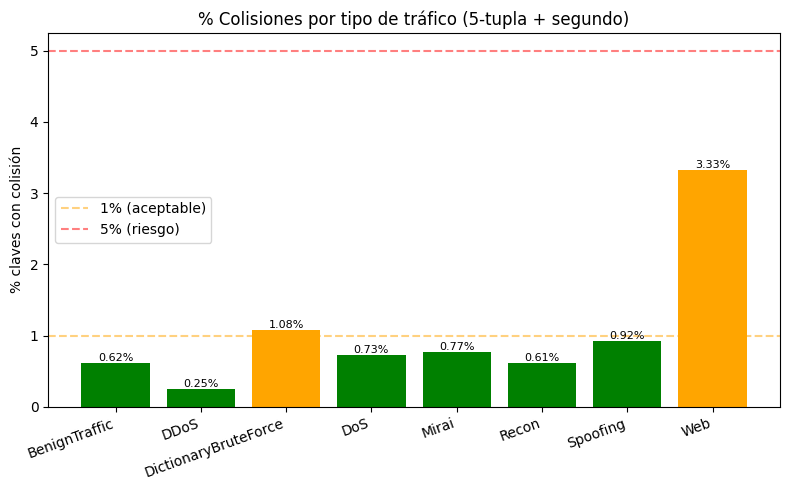

In [15]:
# ============================================================
# CELDA 5 - GRÁFICA 1: % Colisiones
# ============================================================
import matplotlib.pyplot as plt

colores = ["green" if r == "✓ SEGURO" else "orange"
           for r in df_resumen["Riesgo"]]

plt.figure(figsize=(8, 5))
bars = plt.bar(df_resumen["Tipo"], df_resumen["%Colisión"], color=colores)
plt.title("% Colisiones por tipo de tráfico (5-tupla + segundo)")
plt.ylabel("% claves con colisión")
plt.xticks(rotation=20, ha="right")
plt.axhline(y=1, color="orange", linestyle="--", alpha=0.5, label="1% (aceptable)")
plt.axhline(y=5, color="red",    linestyle="--", alpha=0.5, label="5% (riesgo)")
plt.legend()
for bar, val in zip(bars, df_resumen["%Colisión"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

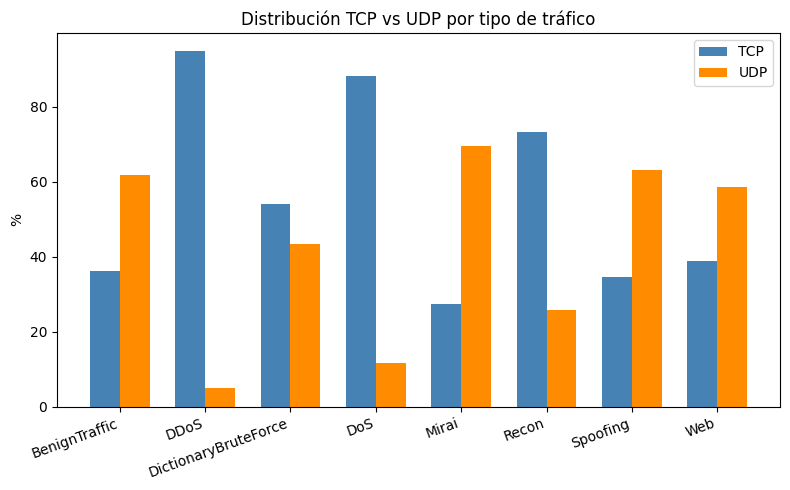

In [14]:
# ============================================================
# CELDA 6 - GRÁFICA 2: TCP vs UDP
# ============================================================
import matplotlib.pyplot as plt

x     = range(len(df_resumen))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], df_resumen["TCP%"],
        width, label="TCP", color="steelblue")
plt.bar([i + width/2 for i in x], df_resumen["UDP%"],
        width, label="UDP", color="darkorange")
plt.title("Distribución TCP vs UDP por tipo de tráfico")
plt.ylabel("%")
plt.xticks(list(x), df_resumen["Tipo"], rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()